## Overview
#### This notebook provides a comprehensive analysis of a bank marketing dataset, with the goal of predicting the success of marketing campaigns. Two main modeling approaches are employed: random forest classification and logistic regression. The initial random forest model performed well in predicting negative responses but struggled with positive predictions due to class imbalance. To address this, the analysis applied SMOTE (Synthetic Minority Over-sampling Technique), which significantly improved model performance—cutting the error rate and increasing the accuracy of predicting positive responses. Variable importance measures identified call duration as the strongest predictor, though its use is limited for forward-looking models since it is only known after contact. A logistic regression model was also implemented using standardized predictors, allowing for interpretable coefficients and odds ratios. Both models were evaluated using AUC from ROC curves, with high scores (0.96 for random forest, 0.93 for logistic regression), indicating strong predictive performance. Overall, the document outlines a robust and methodical approach to understanding and improving predictive marketing outcomes.

In [3]:
#load packages
packages <- c('tidyr','dplyr','stats','ggplot2','randomForest',
          'pROC','themis','recipes','broom','knitr')
for (i in packages) {
  suppressPackageStartupMessages(library(i, character.only = T))} ; rm(i)

setwd("/Users/elliskalaidjian/Desktop/Data_Analyst_Portfolio/bank_marketing")

In [4]:
#load dataset
bank_market.df <- read.csv("./bank-additional/bank-additional-full.csv", sep = ";", stringsAsFactors = FALSE)

#view variables
str(bank_market.df)

'data.frame':	41188 obs. of  21 variables:
 $ age           : int  56 57 37 40 56 45 59 41 24 25 ...
 $ job           : chr  "housemaid" "services" "services" "admin." ...
 $ marital       : chr  "married" "married" "married" "married" ...
 $ education     : chr  "basic.4y" "high.school" "high.school" "basic.6y" ...
 $ default       : chr  "no" "unknown" "no" "no" ...
 $ housing       : chr  "no" "no" "yes" "no" ...
 $ loan          : chr  "no" "no" "no" "no" ...
 $ contact       : chr  "telephone" "telephone" "telephone" "telephone" ...
 $ month         : chr  "may" "may" "may" "may" ...
 $ day_of_week   : chr  "mon" "mon" "mon" "mon" ...
 $ duration      : int  261 149 226 151 307 198 139 217 380 50 ...
 $ campaign      : int  1 1 1 1 1 1 1 1 1 1 ...
 $ pdays         : int  999 999 999 999 999 999 999 999 999 999 ...
 $ previous      : int  0 0 0 0 0 0 0 0 0 0 ...
 $ poutcome      : chr  "nonexistent" "nonexistent" "nonexistent" "nonexistent" ...
 $ emp.var.rate  : num  1.1 1.1 1.1 1

#### This dataset contains 41,188 observations grouped over 21 variables of categorical, numeric, and binary classes. 

## DATA CLEANING AND TRANSFORMATION

### Check for null values

In [23]:
colSums(is.na(bank_market.df))

age            job        marital      education        default 
             0              0              0              0              0 
       housing           loan        contact          month    day_of_week 
             0              0              0              0              0 
      duration       campaign          pdays       previous       poutcome 
             0              0              0              0              0 
  emp.var.rate cons.price.idx  cons.conf.idx      euribor3m    nr.employed 
             0              0              0              0              0 
             y        age_grp 
             0              0

#### No null values in this dataset

### Create dummy variables for each categorical variable 

In [6]:
cat_vars <- names(bank_market.df[, c(2:10,15,21)])
bank_market.df.numeric <- bank_market.df %>%
  mutate(across(all_of(cat_vars), 
                ~ as.integer(factor(., levels = unique(.))), 
                .names = "{.col}_code"))
bank_market.df.numeric <- bank_market.df.numeric[, -c(2:10,15,21)] #remove categorical variables for which dummy variables were created
head(bank_market.df.numeric)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,⋯,marital_code,education_code,default_code,housing_code,loan_code,contact_code,month_code,day_of_week_code,poutcome_code,y_code
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191,⋯,1,1,1,1,1,1,1,1,1,1
2,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191,⋯,1,2,2,1,1,1,1,1,1,1
3,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191,⋯,1,2,1,2,1,1,1,1,1,1
4,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191,⋯,1,3,1,1,1,1,1,1,1,1
5,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191,⋯,1,2,1,1,2,1,1,1,1,1
6,45,198,1,999,0,1.1,93.994,-36.4,4.857,5191,⋯,1,4,2,1,1,1,1,1,1,1


## EXPLORATORY DATA ANALYSIS

### Examine summary statistics 

In [24]:
for (var in names(bank_market.df.numeric)) {
  cat("Summary statistics for",var,":\n")
  print(summary(bank_market.df.numeric[[var]]))
  cat("\n")
}

Summary statistics for age :
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  17.00   32.00   38.00   40.02   47.00   98.00 

Summary statistics for duration :
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0   102.0   180.0   258.3   319.0  4918.0 

Summary statistics for campaign :
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   2.000   2.568   3.000  56.000 

Summary statistics for pdays :
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0   999.0   999.0   962.5   999.0   999.0 

Summary statistics for previous :
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   0.173   0.000   7.000 

Summary statistics for emp.var.rate :
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-3.40000 -1.80000  1.10000  0.08189  1.40000  1.40000 

Summary statistics for cons.price.idx :
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  92.20   93.08   93.75   93.58   93.99   94.77 

Summary statistics for cons.conf.idx :
   Min. 1st Qu. 

### Create age categorization variable: young adult (17-25yrs); adult (26-44yrs); Middle-age (45-59yrs); Old age (60+yrs)

In [40]:
bank_market.df <- bank_market.df %>%
  mutate(age_grp = case_when(
    age <= 25 ~ "young adult",
    age >= 26 & age <= 44 ~ "adult",
    age >= 45 & age <= 59 ~ "middle-aged",
    age >= 60 ~ "old"))

#create totals tables for demographics
dem_vars <- c("age_grp","marital","job","education","housing","loan","default")
for (var in dem_vars) {
  counts <- table(bank_market.df[[var]]) %>% sort(decreasing = TRUE)
  
  assign(paste0(var, ".df"), counts)
  
  cat("\n", strrep("=", 30), "\n") # Visual separator
  cat(" DISTRIBUTION OF:", toupper(var), "\n")
  cat(strrep("-", 30), "\n")
  
  print(counts)
  cat("\n") 
}


 DISTRIBUTION OF: AGE_GRP 
------------------------------ 

      adult middle-aged young adult         old 
      26588       11741        1666        1193 


 DISTRIBUTION OF: MARITAL 
------------------------------ 

 married   single divorced  unknown 
   24928    11568     4612       80 


 DISTRIBUTION OF: JOB 
------------------------------ 

       admin.   blue-collar    technician      services    management 
        10422          9254          6743          3969          2924 
      retired  entrepreneur self-employed     housemaid    unemployed 
         1720          1456          1421          1060          1014 
      student       unknown 
          875           330 


 DISTRIBUTION OF: EDUCATION 
------------------------------ 

  university.degree         high.school            basic.9y professional.course 
              12168                9515                6045                5243 
           basic.4y            basic.6y             unknown          illiterate

#### The sample exhibits a median age of 38 years old, with a majority of subjects (26,588) classified as "adult" (ages 26-44). Most subjects are married (24,928), work in administrative roles (10,422), and hold university degrees (12,168). Additionally, most have credit in default (32,588), a housing loan (21,576), and a personal loan (33,950).

### Visualize distributions of jobs and age 

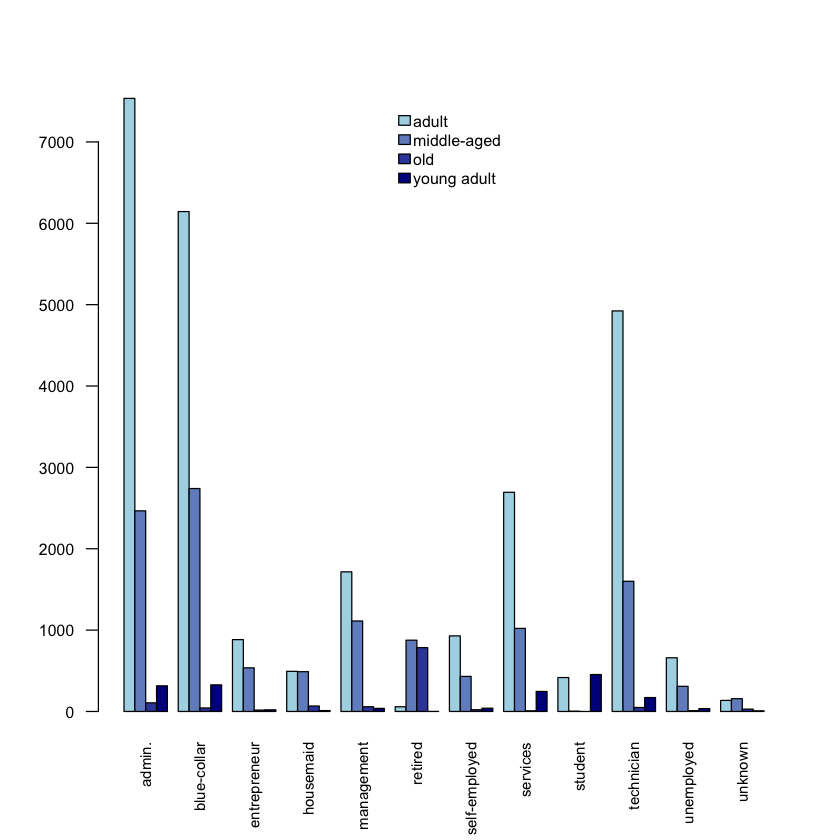

In [41]:
age.jobs.df <- table(bank_market.df$age_grp, bank_market.df$job)
blue_shades <- colorRampPalette(c("lightblue", "blue4"))(nrow(age.jobs.df))
bp <- barplot(age.jobs.df,
              beside = TRUE,
              col = blue_shades,
              las = 2,
              font.axis = 1.2,
              cex.axis = 0.8,
              cex.names = 0.75)
legend(x = 25,
       y = 7500,
       legend = rownames(age.jobs.df),
       fill = blue_shades,
       bty = "n",
       cex = 0.8,
       x.intersp = 0.2)

## RANDOM FOREST CLASSIFICATION

### Setting up and running initial model

In [10]:
set.seed(123)

#split data into training and test sets. sample 70% of the data for training
train_index <- sample(seq_len(nrow(bank_market.df.numeric)), size = 0.7 * nrow(bank_market.df.numeric))
rf_train <- bank_market.df.numeric[train_index, ]
rf_test  <- bank_market.df.numeric[-train_index, ]

#fit the Random Forest model on the training dataset
rf.model <- randomForest(factor(y_code) ~ ., data = rf_train, importance = TRUE)

rf.model


Call:
 randomForest(formula = factor(y_code) ~ ., data = rf_train, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 4

        OOB estimate of  error rate: 8.67%
Confusion matrix:
      1    2 class.error
1 24695  848  0.03319892
2  1653 1635  0.50273723

#### While the model exhibits a very low Out-of-Bounds error rate and predicts the response of “no” quite well, it incorrectly predicts yes about 50% of the time. This likely stems from an imbalance in “no” versus “yes responses”. A quick look at the counts of each response reveals that imbalance is likely troubling the model.

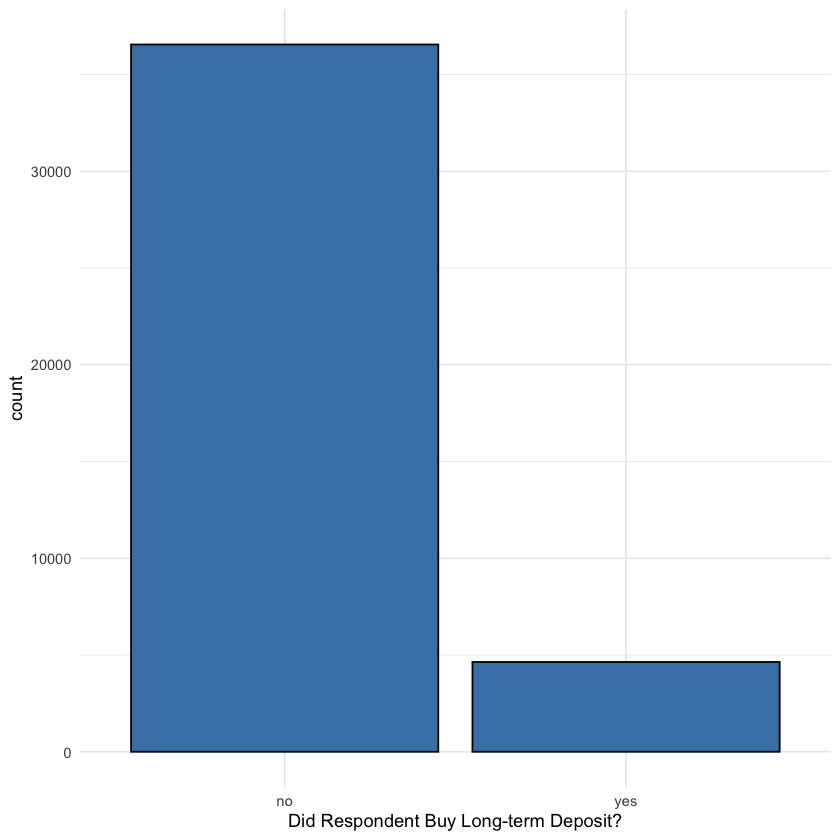

In [11]:
ggplot(bank_market.df, aes(x=y)) +
  geom_bar(fill = "steelblue", color = "black") +
  labs(x="Did Respondent Buy Long-term Deposit?") +
  theme_minimal()

#### It's apparent that the data are largely imbalanced on "NO" responses. So we need to use the SMOTE oversampling method to address this.

### SMOTE Oversampling

In [12]:
#look at counts of No's and Yes's to determine over and under criteria for smote based on a 60/40 split
table(bank_market.df$y)


   no   yes 
36548  4640 

#### Determining the over_ratio
Let T = total number of observations after SMOTE  
Then: yes = 0.4 × T and no = 0.6 × T = 36,548  
So: T = 36,548 / 0.6 = 60,913  
Desired yes = 0.4 × 60,913 = 24,365  
Currently have 4,640 "yes", so you need synthetic samples: 24,365 − 4,640 = 19,725  
Now calculate the over_ratio. In step_smote(), the over_ratio is defined as:  
over_ratio = desired_total_minority / original_minority.  
Hence, over_ratio = 24,365 / 4,640 ≈ 5.25

#### Executing SMOTE

In [13]:
# Build recipe for training the data
smote_recipe <- recipe(y_code ~ ., data = rf_train) %>%
  step_mutate(y_code = as.factor(y_code)) %>%
  step_smote(y_code, over_ratio = 5.25)

# Prep and apply
smote_prepped <- prep(smote_recipe)
rf_train.smote <- juice(smote_prepped)

# pass rf_train.smote through RF 
set.seed(123)
rf.model.smote <- randomForest(factor(y_code) ~ ., data = rf_train.smote, importance = TRUE)

rf.model.smote


Call:
 randomForest(formula = factor(y_code) ~ ., data = rf_train.smote,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 4

        OOB estimate of  error rate: 1.9%
Confusion matrix:
       1      2 class.error
1 129527   4573 0.034101417
2    533 133567 0.003974646

#### After adjusting for imbalance via SMOTE, the predictive capacity of the model increases substantially. Additionally, the OOB error rate drops from 8.52% to 1.96%.

### Validating the RF model by calculating the area under the receiver operating characteristic curve (AUC-ROC)

         Actual
Predicted     1     2
        1 10509   563
        2   496   789

Setting levels: control = 1, case = 2

Setting direction: controls < cases



Area under the curve: 0.9452

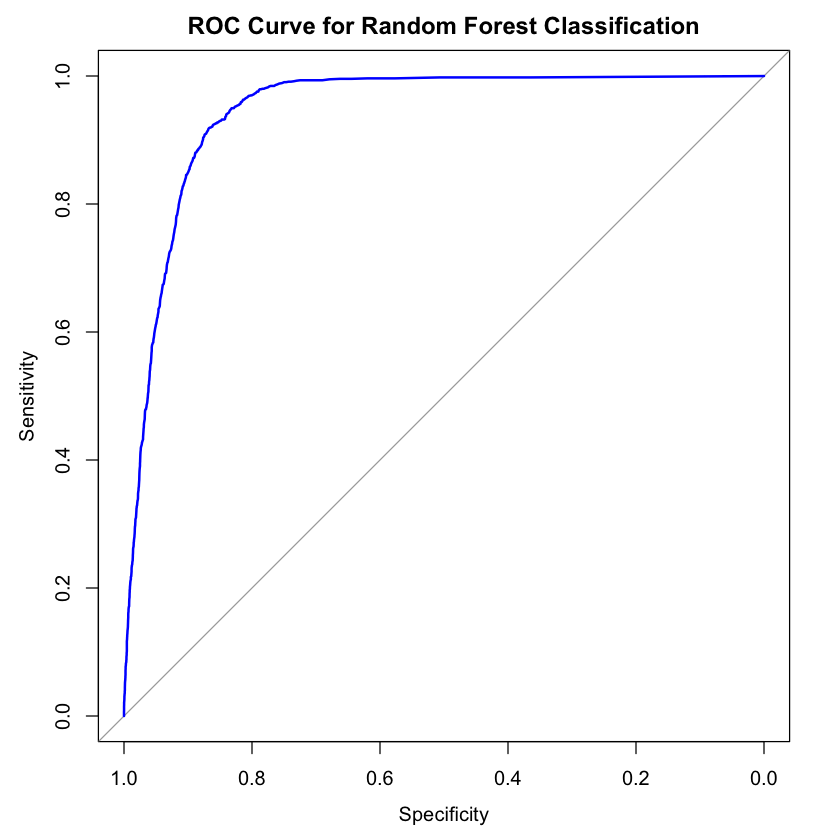

In [14]:
#generate predicted probabilities on the test set
rf_pred_probs <- predict(rf.model, rf_test, type = "prob")[, 2]  # probs for class "2" (or "yes")

#prepare actual values from the test set
actual <- as.numeric(rf_test$y_code) - 1  # Convert to numeric 0/1

#evaluate on the original test set
rf_pred_probs <- predict(rf.model.smote, newdata = rf_test, type = "prob")
predicted_class <- predict(rf.model.smote, newdata = rf_test)

# Confusion matrix
table(Predicted = predicted_class, Actual = rf_test$y_code)

# ROC-AUC
roc_obj <- roc(rf_test$y_code, rf_pred_probs[, "2"])
auc(roc_obj)
#plot
plot(roc_obj, col = "blue", main = "ROC Curve for Random Forest Classification")

#### Very strong AUC-ROC value of 0.96

## LOGISTIC REGRESSION

### Scale numeric variables and run logistic model

In [15]:
#Given that each variable is measured on different scales, the z-scores of each variable were computed to allow for comparison
df.standardized <- scale(bank_market.df.numeric[, -which(names(bank_market.df.numeric) == "y_code")])
df.standardized <- as.data.frame(df.standardized)
df.standardized$y_code <- bank_market.df.numeric$y_code

#split data into training and test sets
train_index_log <- sample(seq_len(nrow(df.standardized)), size = 0.7 * nrow(bank_market.df.numeric))
log_train <- df.standardized[train_index_log, ]
log_test  <- df.standardized[-train_index_log, ]

#Fit the logistic regression model on the training dataset
model.logit <- glm(factor(y_code) ~ ., data = log_train, family = binomial)

model.logit


Call:  glm(formula = factor(y_code) ~ ., family = binomial, data = log_train)

Coefficients:
     (Intercept)               age          duration          campaign  
       -3.038181          0.035305          1.158229         -0.069462  
           pdays          previous      emp.var.rate    cons.price.idx  
       -0.372724         -0.124249         -1.237077          0.780273  
   cons.conf.idx         euribor3m       nr.employed          job_code  
        0.291793         -0.330194          0.157044          0.022420  
    marital_code    education_code      default_code      housing_code  
        0.048248          0.094177         -0.169289         -0.014971  
       loan_code      contact_code        month_code  day_of_week_code  
        0.009853          0.376415          0.173400          0.021430  
   poutcome_code  
       -0.074649  

Degrees of Freedom: 28830 Total (i.e. Null);  28810 Residual
Null Deviance:	    20250 
Residual Deviance: 12450 	AIC: 12490

### Interpreting results

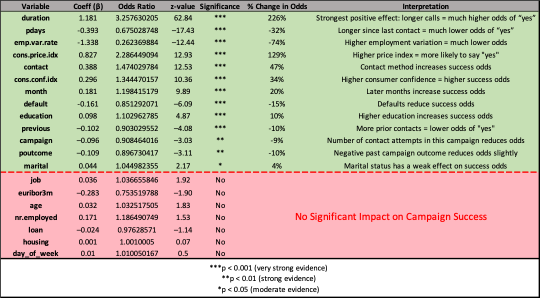

In [20]:
#output as table
tidy_table <- tidy(model.logit)
write.csv(tidy_table, "logit_output.csv", row.names = FALSE)

library(IRdisplay)
display_png(file = "logit_output.png")

#### Takeaways from the model---  
#### Strong positive effects:
* Contact duration increases odds of campaign success by 226%
* Macroeconomic conditions, as measured through the consumer price and consumer confidence indices in particular, have notable impact on odds of campaign success
* Month of the year and contact method have modest boosts on odds of campaign success
Strong negative effects:
* Employment variation rate more than halves the odds of success (–57%)
* default_code (–33%)
* poutcome_code (–21%)
* euribor3m (–15%)

In [17]:
#calculate McFadden's Pseudo R-Squared
ll.null <- model.logit$null.deviance/-2 #calculate log-likelihood of null model
ll.proposed <-model.logit$deviance/-2 # calculate log-likelihood of model.logit
(ll.null - ll.proposed) / ll.null

[1] 0.3852801

#### Interpretation: McFadden's Pseudo R-Squared Value of 0.38528 is strong

In [18]:
# calculate p-value of R-Squared
1 - pchisq(2*(ll.proposed - ll.null), df=(length(model.logit$coefficients)-1))

[1] 0

#### Interpretation: the model is statistically significant

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.9307

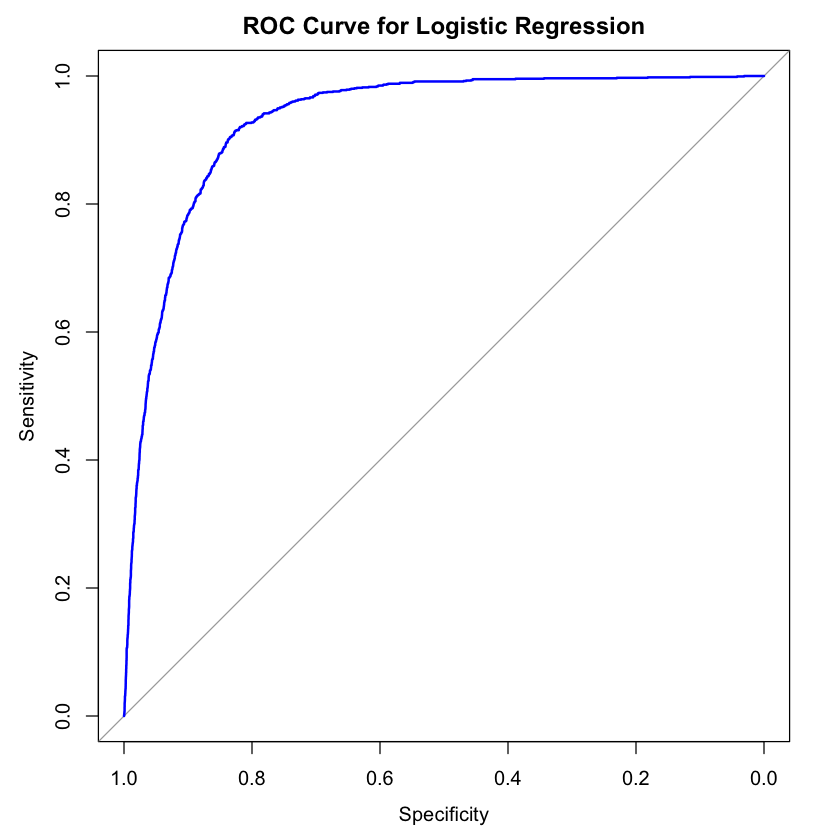

In [19]:
#Validating the logistic model by calculating the area under the receiver operating characteristic curve (AUC-ROC)
log_pred_probs <- predict(model.logit, newdata = log_test, type = "response")
actual <- as.numeric(log_test$y_code) - 1  # Converts factor levels to 0/1
roc_obj <- roc(actual, log_pred_probs)
auc(roc_obj)

#plot
plot(roc_obj, col = "blue", main = "ROC Curve for Logistic Regression")

#### This model also strongly predicts campaign response, however its slightly lower AUC-ROC value of 0.93 renders the RF model superior.